In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from legendkit import legend
from legendkit.layout import vstack, hstack

In [2]:
def calc_psi(v, isopycs, topo):
        # function used to calculate the instantaneous overturning stream function psi from simulation output v (meridional velocity), isopycnal surfaces (isopycs) and bathimetry (topo).
    
        # mask arrays
        
        v_masked = v.where(topo < 0)
        isopycs_masked = isopycs.where(topo < 0)
        
        # now let's look at the streamfunction as a velocity integral in z space.
        
        N_z = 200
        N_x = 2048
        N_y = 1024
        
        lon = np.linspace(v_masked.x.values[0], v_masked.x.values[-1], N_x)
        lat = np.linspace(v_masked.y.values[0], v_masked.y.values[-1], N_y)
        z = np.linspace(-6000, 20, N_z)
        
        # create interpolation of original dataset.
        
        v_grid = xr.Dataset(dict(v = (["z", "y", "x"], np.zeros([N_z, N_y, N_x]))), coords=dict(
                z=("z", z),
                y=("y", lat),
                x=("x", lon)))
        
        # fill up array with layer values
        v_z = v_grid["v"].copy()
        
        # fill up lower layer
        v_z = xr.where(v_z.z > -20000, v_masked[0,:,:].drop_vars('level'), v_masked[0,:,:].drop_vars('level'))
        
        # fill up remaining layers
        for n in range(4):
            v_z = xr.where(v_z.z < isopycs_masked[n,:,:].drop_vars('level'), v_z, v_masked[n+1,:,:].drop_vars('level'))
        
        # mask topo and upper bounds
        v_z = v_z.where(v_z.z > topo)
        v_z = v_z.where(v_z.z < isopycs_masked[-1,:,:].drop_vars('level'))
        
        dz = (6000 + 20)/N_z
        dlon = v.x[1] - v.x[0]
        R = 6378e3
        dx = dlon/180*np.pi*np.cos(v.y/180*np.pi)*R
        
        v_mer = v_z.sum("x", skipna = "True")*dx
        
        psi = v_mer[::-1,:].cumsum("z")[::-1,:]*dz
        
        return psi

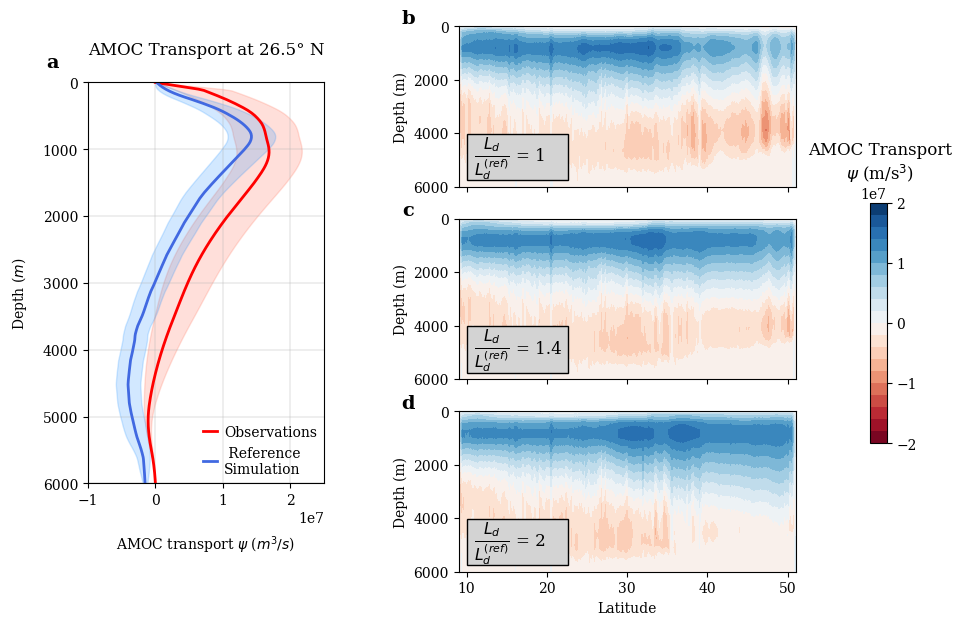

In [8]:
drho_facs = [1, 2, 4]

plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(3, 2, figsize=(12/1.2, 8.5/1.2))
plt.subplots_adjust(hspace=0.2, wspace=0.3)

cmap = "RdBu"
Rd_labels = ["0", "1", "1.4", "2"]


# upper right. L_d/L_d^ref = 1

v = 20e6
levels = np.linspace(-v, v, 21)

ds = xr.open_dataset("data/gulf_1drho/Psi_mean.nc")
psi = ds["__xarray_dataarray_variable__"]
axes = ax[0,1] 
axes.pcolormesh(psi.y, psi.z, psi, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(psi.y, psi.z, psi, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.set_ylim([-6000, 0])

axes.set_ylabel("Depth (m)")
axes.set_yticks([0,-2000,-4000, -6000])
axes.set_yticks(ticks = axes.get_yticks(), labels = [f"{abs(tick):.0f}" for tick in axes.get_yticks()])
axes.set_xticklabels([])

# add text for deformation radius
axes.add_patch(Rectangle([0.025, 0.04], 0.3, 0.29, transform=axes.transAxes, facecolor = "lightgray", linewidth = 1, linestyle = "-", edgecolor = "k", zorder = 2))
axes.text(0.1, 0.18, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16, zorder = 2)
axes.text(0.17, 0.19, '= ' + Rd_labels[1], verticalalignment='center', transform=axes.transAxes, size = 12, zorder = 2)

# add text for deformation radius
axes.text(-0.15, 1.05, "b", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 14)



# middle right. L_d/L_d^ref = 1.4

v = 20e6
levels = np.linspace(-v, v, 21)

ds = xr.open_dataset("data/gulf_2drho/Psi_mean.nc")
psi = ds["__xarray_dataarray_variable__"]
axes = ax[1,1] 
axes.pcolormesh(psi.y, psi.z, psi, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(psi.y, psi.z, psi, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.set_ylim([-6000, 0])

axes.set_ylabel("Depth (m)")
axes.set_yticks([0,-2000,-4000, -6000])
axes.set_yticks(ticks = axes.get_yticks(), labels = [f"{abs(tick):.0f}" for tick in axes.get_yticks()])
axes.set_xticklabels([])

# add text for deformation radius
axes.add_patch(Rectangle([0.025, 0.04], 0.3, 0.29, transform=axes.transAxes, facecolor = "lightgray", linewidth = 1, linestyle = "-", edgecolor = "k", zorder = 2))
axes.text(0.1, 0.18, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16, zorder = 2)
axes.text(0.17, 0.19, '= ' + Rd_labels[2], verticalalignment='center', transform=axes.transAxes, size = 12, zorder = 2)

# add text for deformation radius
axes.text(-0.15, 1.05, "c", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 14)


# lower right. L_d/L_d^ref = 2

v = 20e6
levels = np.linspace(-v, v, 21)

ds = xr.open_dataset("data/gulf_4drho/Psi_mean.nc")
psi = ds["__xarray_dataarray_variable__"]
axes = ax[2,1] #fig.add_subplot(grid[1,1])
axes.pcolormesh(psi.y, psi.z, psi, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(psi.y, psi.z, psi, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.set_ylim([-6000, 0])

axes.set_ylabel("Depth (m)")

axes.set_yticks([0,-2000,-4000, -6000])
axes.set_yticks(ticks = axes.get_yticks(), labels = [f"{abs(tick):.0f}" for tick in axes.get_yticks()])
axes.set_xlabel("Latitude")

# add text for deformation radius
axes.add_patch(Rectangle([0.025, 0.04], 0.3, 0.29, transform=axes.transAxes, facecolor = "lightgray", linewidth = 1, linestyle = "-", edgecolor = "k", zorder = 2))
axes.text(0.1, 0.18, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16, zorder = 2)
axes.text(0.17, 0.19, '= ' + Rd_labels[3], verticalalignment='center', transform=axes.transAxes, size = 12, zorder = 2)

# add text for deformation radius
axes.text(-0.15, 1.05, "d", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 14)

# colorbar
divider = make_axes_locatable(axes)
cax = axes.inset_axes((1.22, 0.8,0.05, 1.5))
cbar = plt.colorbar(cplot, cax=cax, orientation='vertical', ticks = [-v, -v/2, 0, v/2, v])
axes.text(1.25, 2.45,'AMOC Transport\n' + r'$\psi$ (m/s$^3$)', rotation = 0, ha = "center", transform=axes.transAxes, size = 12)
cax.xaxis.set_label_coords(0,1.25)


# set remaining axes off
ax[1,0].set_axis_off()
ax[2,0].set_axis_off()
ax[0,0].set_axis_off()

axes = ax[0,0].inset_axes((0.2, -1.85,0.7, 2.5))

# add RAPID data.
ds = xr.open_dataset("data/moc_vertical.nc")
psi_rapid = ds["stream_function_mar"]*1e6

ds = xr.open_dataset("data/gulf_1drho/Psi_mean.nc")
psi_bas = ds["__xarray_dataarray_variable__"].sel(y = 26.5, method = "nearest")
ds = xr.open_dataset("data/gulf_1drho/Psi_std.nc")
psi_bas_std = ds["__xarray_dataarray_variable__"].sel(y = 26.5, method = "nearest")

# Plot Rapid data
axes.plot(psi_rapid.mean(dim = "time"), -psi_rapid.depth, linewidth = 2, linestyle = '-', color = "red", label = "Observations")

# add error bars
axes.fill_betweenx(-psi_rapid.depth, psi_rapid.mean(dim = "time") - psi_rapid.std(dim = "time"), psi_rapid.mean(dim = "time") + psi_rapid.std(dim = "time"), alpha = 0.2, color = "tomato")

# Plot simulation data
axes.plot(psi_bas, psi_bas.z, linewidth = 2, linestyle = '-', color = "royalblue", label = " Reference\nSimulation")

# add error bars
axes.fill_betweenx(psi_bas.z, psi_bas - psi_bas_std,psi_bas + psi_bas_std, alpha = 0.2, color = "dodgerblue")

axes.legend()

axes.set_title("AMOC Transport at 26.5° N", y = 1.05)

axes.set_xlabel(r"AMOC transport $\psi$ ($m^3/s$)")
axes.xaxis.set_label_coords(0.5,-0.125)

axes.set_ylabel("Depth ($m$)")
axes.set_yticks(ticks = axes.get_yticks(), labels = [f"{abs(tick):.0f}" for tick in axes.get_yticks()])
axes.yaxis.set_label_coords(-0.25,0.475)

axes.grid(zorder = 1, linewidth = 0.3)
axes.set_xlim([-10*1e6, 25*1e6])
axes.set_ylim([-6000, 0])

# add text for deformation radius
axes.text(-0.15, 1.05, "a", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 14)

plt.savefig('AMOC_psi_and_validate.png', dpi = 400, bbox_inches='tight', format = 'png')